# Modelos de regresión lineal regularizados

La regularizaciòn es una estrategia para reducir la complejidad de los modelos a través del control del tamaño de los coeficientes. Con esta estrategia se busca reducir la **varianza** del modelo, sin aumentar su **sesgo**.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Nuevamente, vamos a trabajar con un dataset sintético con una solo 2 variables, una de entrada, y otra de salida.

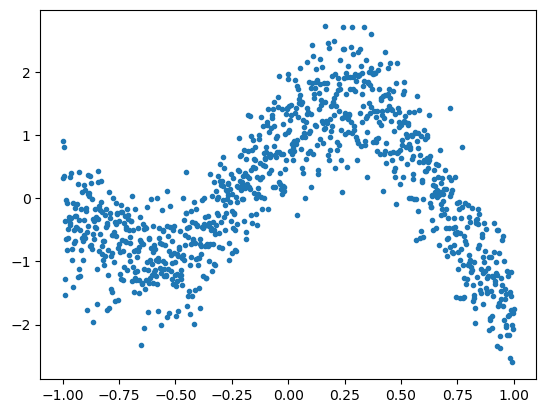

In [15]:
X = np.linspace(-1, 1, 1000)
ruido = np.random.normal(0, 0.5, 1000)
y = np.sin(4*X) + np.cos(3*X) + ruido
X = X.reshape(-1,1)
plt.plot(X,y, '.');

Vamos a encontrar el modelo polinómico que menor error tenga:

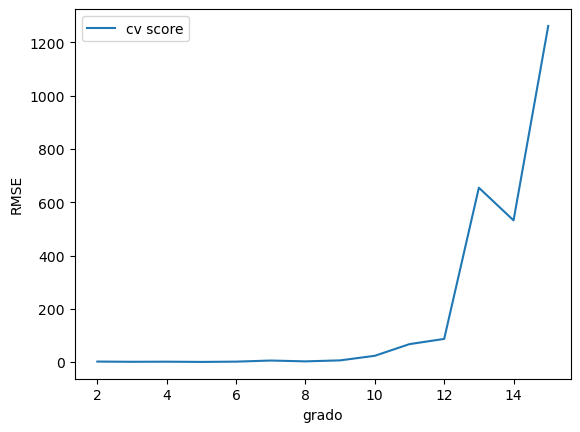

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees = range(2,16)
mean_scores_cv = []
for degree in degrees:
  poly = PolynomialFeatures(degree = degree, include_bias=False)
  X_p = poly.fit_transform(X)
  score = cross_val_score(estimator = LinearRegression(), X=X_p , y=y, cv=5,
                          scoring='neg_root_mean_squared_error')
  mean_scores_cv.append(-score.mean())
plt.plot(degrees, mean_scores_cv, '-', label='cv score')
plt.legend()
plt.xlabel('grado')
plt.ylabel('RMSE');

In [17]:
print(f'El mejor RMSE es {np.min(mean_scores_cv):.3f}, obtenido con un grado de polinomio {degrees[np.argmin(mean_scores_cv)]}.')

El mejor RMSE es 0.640, obtenido con un grado de polinomio 5.


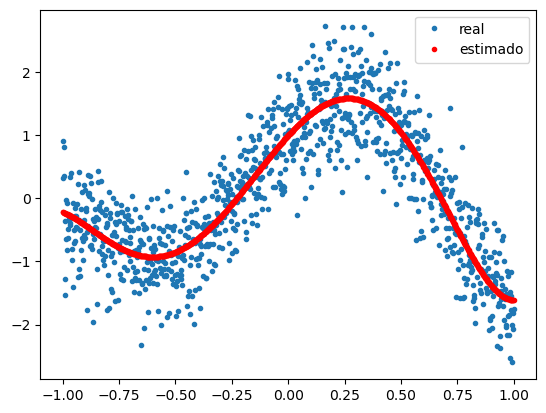

In [18]:
poly = PolynomialFeatures(degree = degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_p = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_p, y)
y_est = model.predict(X_p)

plt.plot(X, y, '.', label ='real')
plt.plot(X, y_est, '.r', label = 'estimado')
plt.legend();

Los coeficientes de este modelo son:

In [19]:
print(f'Coeficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

Coeficients: [ 3.90098278 -4.1879784  -9.182203    2.27271367  4.58612927]
Intercept: 0.9994920404578064


# Modelo Ridge

Ahora vamos a aplicar modelos regularizados para ver si obtenemos un mejor desempeño.

Estos modelos tienen un hiperparámetro llamado $\lambda$ con el que se controla cuanto reducir la complejidad. $\lambda$ puede tomar valores en el rango $[0, \infty)$, y mientras más grande sea más reduce el tamaño de los coeficientes y más reduce la complejidad del modelo.

En Scikit Learn estos modelos están implementados en las clases Ridge() y Lasso(), y el factor de regularización se llama alpha.

In [20]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

poly = PolynomialFeatures(degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_p = poly.fit_transform(X)

model = Ridge(alpha=1)

score = cross_val_score(model, X_p, y, cv=5, scoring='neg_root_mean_squared_error')
print(f'RMSE de validación con alpha = 1: {-score.mean():.3f}')
model.fit(X_p, y)
print(f'Coeficientes: {model.coef_}')
print(f'Intercept: {model.intercept_}')

RMSE de validación con alpha = 1: 0.948
Coeficientes: [ 2.75967288 -3.4884301  -4.37774261  1.50371397  0.50653973]
Intercept: 0.9202586095826389


Vamos a evaluar este modelo por validación cruzada para tener una aproximación más realista de su verdadero **error de generalización**. Vamos a probar nuestro modelo con diferentes valores de $\lambda$.

In [21]:
from sklearn.model_selection import cross_val_score

poly = PolynomialFeatures(degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_p = poly.fit_transform(X)

alphas = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
for alpha in alphas:
  model = Ridge(alpha = alpha)
  score = cross_val_score(model, X_p, y, cv=5, scoring='neg_root_mean_squared_error')
  print(f'RMSE de validación con alpha = {alpha}: {-score.mean():.3f}')
  model.fit(X_p, y)
  print(f'Coeficientes: {model.coef_}')

RMSE de validación con alpha = 0: 0.640
Coeficientes: [ 3.90098278 -4.1879784  -9.182203    2.27271367  4.58612927]
RMSE de validación con alpha = 0.001: 0.642
Coeficientes: [ 3.89813257 -4.18707023 -9.16988412  2.27171088  4.5755141 ]
RMSE de validación con alpha = 0.01: 0.673
Coeficientes: [ 3.8728717  -4.17892108 -9.06073461  2.26271309  4.48147429]
RMSE de validación con alpha = 0.1: 0.809
Coeficientes: [ 3.65369164 -4.09977376 -8.1162997   2.17536233  3.66901144]
RMSE de validación con alpha = 1: 0.948
Coeficientes: [ 2.75967288 -3.4884301  -4.37774261  1.50371397  0.50653973]
RMSE de validación con alpha = 10: 1.199
Coeficientes: [ 1.76930882 -1.87435181 -1.53588872 -0.17659466 -1.26639231]
RMSE de validación con alpha = 100: 1.253
Coeficientes: [ 0.60147507 -0.83196305 -0.36840085 -0.54940144 -0.47894009]
RMSE de validación con alpha = 1000: 1.278
Coeficientes: [ 0.09911556 -0.1736991  -0.03206285 -0.13509332 -0.05252189]


Se observa que el error de validación baja cuando se incrementa el valor de $\lambda$, pero hasta cierto punto, porque después vuelve a subir.

Por otra parte, el tamaño de los coeficientes si baja a medida que se aumenta el valor de $\lambda$.

# Sintonización de hiperparámetros

Dado que $\lambda$ puede tomar un rango muy amplio de valores (desde 0 hasta $\infty$), encontrar el valor óptimo con el que se obtenga el **menor error de validación** es un gran desafío.

Lo que se puede hacer es probar con un gran número de valores, y de estos valores seleccionar el que de mejores resultados. Este proceso se conoce como **sintonización de hiperparámetros**.

Otro problema aquí es que para saber que valor del hiperparámetro da mejores resultados se debería evaluar con datos diferentes a los datos con los que se entrena el modelo, pero estos a la vez deberían ser diferentes a los datos con los que se evalúa el modelo ya ajustado y con los hiperparámetros seleccionados. Esto implica que de nuestro dataset debemos sacar 3 subconjuntos:
- Un subconjunto para entrenar el modelo con cada hiperparámetro.
- Un subconjunto para evaluar el modelo ajustado con cada hiperparámetro.
- Un subconjunto para evaluar el modelo ajustado con el hiperparámetro ya seleccionado.

Estos 3 subconjuntos se conocen respectivamente como conjunto de datos de **entrenamiento**, **validación** y **prueba**. A esto hay que añadir que lo idela sería entrenar y validar cada hiperparámetro con varios conjuntos de datos, para evitar sesgo y saber que tanta varianza tiene.

Dado todo lo anterior, habría que hacer una primera partición de los datos, antes de hacer cualquier procesamiento a la matriz de características y de entrenar los modelos. Esto es Scikit Learn se puede hacer con el método train_test_split. De esta manera nos quedaría un subconjunto de datos para sintonizar los hiperparámetros, que llamaremos por ahora **dataset de entrenamiento**, y otro para evaluar los modelos con los hiperparámetros ya sintonizados y ajustados, que llamaremos **dataset de prueba**.



In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (800, 1)
Tamaño del conjunto de prueba es: (200, 1)


Con el dataset de prueba no se hará nada hasta el final.

Ahora, la obtención de los subconjuntos de entrenamiento y validación para sintonizar hiperparámetros puede hacerse por validación cruzada. Aunque el método cross_val_score nos serviría, existen en Scikit Learn clases especializadas para hacer sintonización de hiperparámetros por validación cruzada, uno de los cuales es **GridSearchCV**.

In [23]:
from sklearn.model_selection import GridSearchCV

poly = PolynomialFeatures(degrees[np.argmin(mean_scores_cv)], include_bias=False)
X_train_p = poly.fit_transform(X_train)

alpha = np.logspace(-4, 4, 100)

grid = dict(alpha = alpha)

grid_search = GridSearchCV(estimator=model, param_grid=grid, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train_p, y_train)

print(f'Mejor RMSE obtenido fue {-grid_search.best_score_:.3} con lambda de {grid_search.best_params_}.')

Mejor RMSE obtenido fue 0.518 con lambda de {'alpha': 0.012618568830660211}.


**GridSearchCV**, y métodos similares, tienen una ventaja adicional sobre hacer CV de manera manual para sintonizar hiperparámetros, y es que **entregan el mejor modelo ya sintonizado y entrenado**. El mejor modelo se obtiene usando el atributo **best_estimator_**.

Con este, ya es posible hacer predicciones y evaluar el modelo con datos de prueba.

In [24]:
best_model = grid_search.best_estimator_
X_test_p = poly.fit_transform(X_test)
print(f'RMSE de prueba es {np.sqrt(mean_squared_error(y_test, best_model.predict(X_test_p))):.3}.')

RMSE de prueba es 0.514.


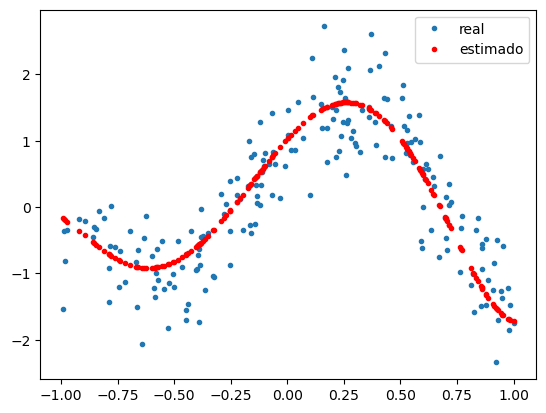

In [25]:
y_est = best_model.predict(X_test_p)
plt.plot(X_test, y_test, '.', label ='real')
plt.plot(X_test, y_est, '.r', label = 'estimado')
plt.legend();

Vemos que este modelo efectivamente tiene menor error. Los coeficientes de este modelo son:

In [26]:
print(f'Las pendientes de este modelo son: {best_model.coef_}')
print(f'El intercepto de este modelo es: {best_model.intercept_}')

Las pendientes de este modelo son: [ 3.76975371 -4.28803012 -8.72545805  2.32514165  4.1731356 ]
El intercepto de este modelo es: 1.0265890268753939


En este caso, la disminución del tamaño de los coeficientes fue mínima, porque el mejor valor encontrado para $\lambda$ fue pequeño. Sin embargo, vemos que esto fue suficiente para mejorar el modelo.

# Ejercicio

Cargar el archivo 'auto-mpg.data', póngale nombre a las columnas de acuerdo a lo indicado en el archivo 'auto-mpg.names'.

Configure como índice la variable 'car_name'.

Haga un modelo de regresión Ridge que prediga la variable 'mpg' usando todas las demás variables disponibles como predictoras. Para esto haga una partición de los datos en subconjuntos de entrenamiento y prueba en una proporciòn 70/30, usando random_state=1.

Reporte el mejor valor de $\lambda$ encontrado, el RMSE de entrenamiento y el de prueba con este valor, el intercepto y los pesos del modelo.